Irene Lega, Benedetta Taricco, Matteo Gobbato. 
# Top Quark Tagging, notebook 2.
# RE-UPLOADING

Questo notebook segue a VQAsemplice.

Qui si realizzano due sistemi di quantum machine lerning per la classificazione dei quark top, utilizzando il dataset fornito dall'esperimento ATLAS del CERN. In entrambi i casi si usa un VQA con PQC. Come loss function si usa la BCE e come ottimizzatore classico ADAM. Si usano 16 features per jet, implementate nel circuito attraverso la tecnica del data re-uploading.
Nel primo caso si studia un PQC di un solo qubit, in cui vengono codificate tutte e 16 le features, una per layer (16 layers totali). Nel secondo caso si aggiungono al PQC 3 qubits, per un totale di 4: in ogni qubit vengono codificate 4 features alla volta, per un totale di 4 layers.
Questo tipo di encoding viene descritto nell'articolo "Data re-uploading for a universal quantum classifier" (A.Pérez-Salinas et al., 2020, https://quantum-journal.org/papers/q-2020-02-06-226/pdf/).

# Autoencoder
Come nel notebook precedente, si utilizza un autoencoder sinkhorn per ottenere le 16 low level features e si divide il dataset in train e test:

DataLoader pronto! Numero batch: 40

Training AE | latent=16, early_stop=30

  ✓ new best: 1.44061
Epoch 1/200 | train=1.48573  valid=1.44061  recon=0.95526  sink=0.00199  cls=0.69251  [!] cls~random
  ✓ new best: 1.22995
Epoch 2/200 | train=1.39733  valid=1.22995  recon=0.76205  sink=0.05068  cls=0.64671
  ✓ new best: 1.13352
Epoch 3/200 | train=1.20977  valid=1.13352  recon=0.72546  sink=0.04852  cls=0.56215
  ✓ new best: 1.08240
Epoch 4/200 | train=1.14508  valid=1.08240  recon=0.69778  sink=0.03517  cls=0.53437
  ✓ new best: 1.05307
Epoch 5/200 | train=1.10586  valid=1.05307  recon=0.67956  sink=0.01674  cls=0.52641
  ✓ new best: 1.03666
Epoch 6/200 | train=1.06728  valid=1.03666  recon=0.65086  sink=0.02642  cls=0.53982
  ✓ new best: 0.98643
Epoch 7/200 | train=1.02480  valid=0.98643  recon=0.61121  sink=0.02994  cls=0.52320
  ✓ new best: 0.95241
Epoch 8/200 | train=0.97685  valid=0.95241  recon=0.58504  sink=0.01852  cls=0.51687
  ✓ new best: 0.91784
Epoch 9/200 | train=0.95307  

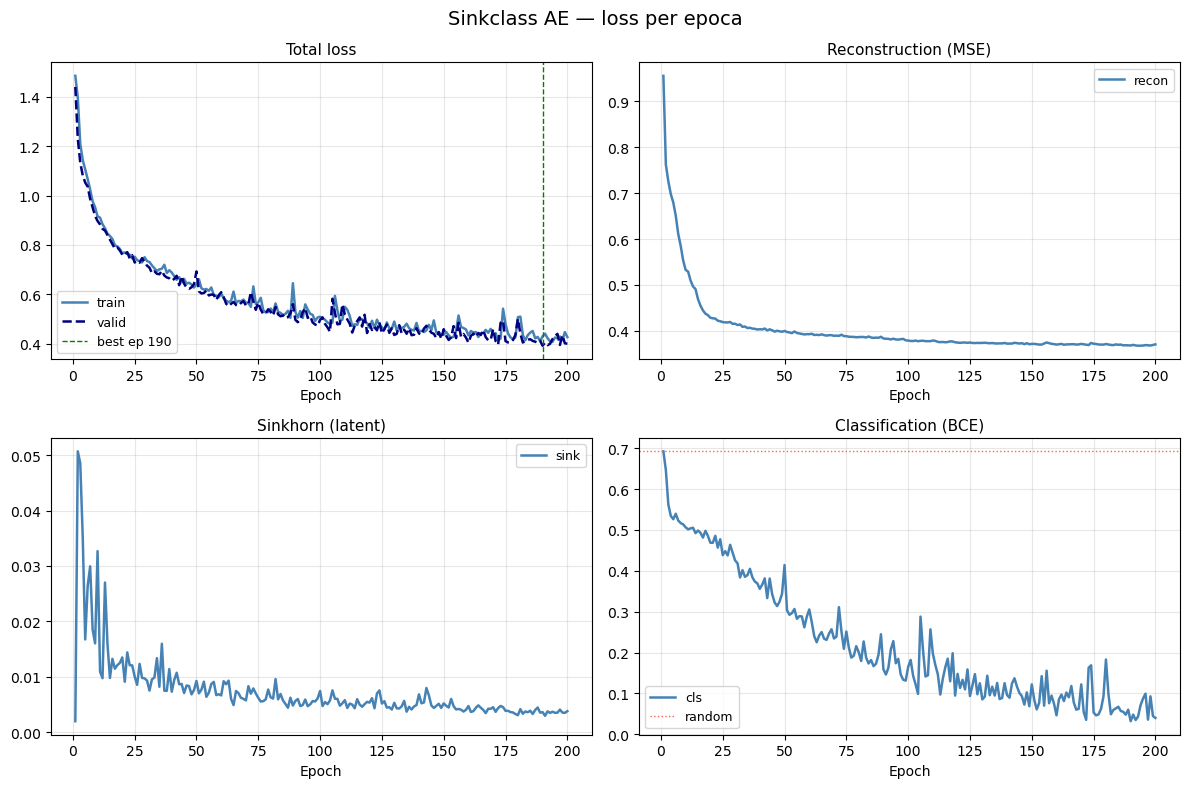

In [1]:
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import geomloss
import matplotlib.pyplot as plt
import os
import pennylane as qml
import pennylane.numpy as pnp
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ================================================================
# PARTE 1 — CARICA DATI
# ================================================================

infile = "train_nominal_000.h5"
f = h5py.File(infile, 'r')
Njet = 10000
NConstituents = 100

clus_E   = f['fjet_clus_E'][:Njet,   :NConstituents]
clus_eta = f['fjet_clus_eta'][:Njet,  :NConstituents]
clus_phi = f['fjet_clus_phi'][:Njet,  :NConstituents]
clus_pt  = f['fjet_clus_pt'][:Njet,   :NConstituents]
labels   = f["labels"][:Njet]

X = np.concatenate([
    clus_pt.reshape(Njet, -1),
    clus_eta.reshape(Njet, -1),
    clus_phi.reshape(Njet, -1),
    clus_E.reshape(Njet, -1)
], axis=1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(labels, dtype=torch.float32)
dataset  = TensorDataset(X_tensor, y_tensor)

train_loader = DataLoader(dataset, batch_size=256, shuffle=True)
valid_loader = DataLoader(dataset, batch_size=512, shuffle=False)
print("DataLoader pronto! Numero batch:", len(train_loader))


# ================================================================
# PARTE 2 — AUTOENCODER SINKCLASS
# ================================================================

class AE_sinkclass(nn.Module):
    def __init__(self, device="cpu", hpars=None):
        super().__init__()
        self.device = device
        self.hp = {
            "ae_type":          "sinkclass",
            "ae_layers":        [400, 256, 128, 64, 32, 16],  # latent = 16
            "lr":               0.0005,
            "adam_betas":       (0.9, 0.999),
            "labels_dimension": 2,
            "class_weight":     0.7,
            "sinkh_weight":     0.3,
            "class_layers":     [64, 32, 16, 1],
        }
        if hpars:
            self.hp.update({k: hpars[k] for k in hpars.keys() & self.hp.keys()})

        latent_dim = self.hp["ae_layers"][-1]   # 16
        labels_dim = self.hp["labels_dimension"]

        self.encoder    = self._build_mlp(self.hp["ae_layers"], final_activation=False)
        self.decoder    = self._build_mlp(list(reversed(self.hp["ae_layers"])), final_activation=True)
        self.classifier = self._build_classifier([latent_dim] + self.hp["class_layers"])

        first_hidden = self.hp["ae_layers"][1]
        self.noise_enc_data = nn.Sequential(
            nn.Linear(self.hp["ae_layers"][0], first_hidden), nn.LeakyReLU(0.2),
            nn.Linear(first_hidden, first_hidden),            nn.LeakyReLU(0.2),
        )
        self.noise_enc_labl = nn.Sequential(
            nn.Linear(labels_dim, first_hidden), nn.LeakyReLU(0.2),
        )
        self.noise_gen = nn.Sequential(
            nn.Linear(2 * first_hidden, first_hidden), nn.LeakyReLU(0.2),
            nn.Linear(first_hidden, first_hidden // 2),  nn.LeakyReLU(0.2),
            nn.Linear(first_hidden // 2, latent_dim),
        )

        self.recon_loss_fn = nn.MSELoss(reduction="mean")
        self.class_loss_fn = nn.BCELoss(reduction="mean")
        self.laten_loss_fn = geomloss.SamplesLoss("sinkhorn", blur=0.05, scaling=0.95, diameter=0.01, debias=True)

        self.best_valid_loss   = float("inf")
        self.epochs_no_improve = 0
        self.early_stop_limit  = 30
        self.all_train_loss, self.all_valid_loss = [], []
        self.all_recon_loss, self.all_laten_loss, self.all_class_loss = [], [], []
        self.to(self.device)

    @staticmethod
    def _build_mlp(layers, final_activation=True):
        mods = []
        for i in range(len(layers) - 1):
            mods.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                mods.append(nn.ReLU(True))
            elif final_activation:
                mods.append(nn.Tanh())
        return nn.Sequential(*mods)

    @staticmethod
    def _build_classifier(layers):
        mods = []
        for i in range(len(layers) - 1):
            mods.append(nn.Linear(layers[i], layers[i + 1]))
            mods.append(nn.Sigmoid() if i == len(layers) - 2 else nn.LeakyReLU(0.2))
        return nn.Sequential(*mods)

    def _onehot(self, y_batch):
        B = y_batch.shape[0]
        y_map = torch.zeros(B, self.hp["labels_dimension"], device=y_batch.device)
        return y_map.scatter_(1, y_batch.long().reshape(-1, 1), 1.0)

    def _generate_noise(self, x_noise, y_onehot):
        return self.noise_gen(torch.cat([self.noise_enc_data(x_noise),
                                         self.noise_enc_labl(y_onehot)], dim=1))

    def forward(self, x):
        latent = self.encoder(x)
        return latent, self.classifier(latent), self.decoder(latent)

    def compute_loss(self, x_data, y_data):
        y_onehot     = self._onehot(y_data)
        latent, classif, recon = self.forward(x_data)
        latent_noise = self._generate_noise(torch.rand_like(x_data), y_onehot)
        recon_loss   = self.recon_loss_fn(recon, x_data)
        class_loss   = self.class_loss_fn(classif.flatten(), y_data.float())
        laten_loss   = self.laten_loss_fn(latent, latent_noise)
        return (recon_loss + self.hp["sinkh_weight"] * laten_loss
                + self.hp["class_weight"] * class_loss,
                recon_loss, laten_loss, class_loss)

    def train_autoencoder(self, train_loader, valid_loader, epochs=200, outdir=None):
        optimizer = optim.Adam(self.parameters(), lr=self.hp["lr"], betas=self.hp["adam_betas"])
        print(f"\nTraining AE | latent={self.hp['ae_layers'][-1]}, early_stop={self.early_stop_limit}\n")
        for epoch in range(epochs):
            self.train()
            batch_sum, n = 0.0, 0
            for xb, yb in train_loader:
                xb, yb = xb.to(self.device), yb.to(self.device)
                total, *_ = self.compute_loss(xb, yb)
                optimizer.zero_grad(); total.backward(); optimizer.step()
                batch_sum += total.item(); n += 1
            train_loss = batch_sum / n
            vt, vr, vl, vc = self._validate(valid_loader, outdir)
            self.all_train_loss.append(train_loss); self.all_valid_loss.append(vt)
            self.all_recon_loss.append(vr);         self.all_laten_loss.append(vl)
            self.all_class_loss.append(vc)
            warn = "  [!] cls~random" if vc > 0.68 else ""
            print(f"Epoch {epoch+1}/{epochs} | train={train_loss:.5f}  valid={vt:.5f}  "
                  f"recon={vr:.5f}  sink={vl:.5f}  cls={vc:.5f}{warn}")
            if self.epochs_no_improve >= self.early_stop_limit:
                print(f"Early stopping at epoch {epoch+1}."); break

    @torch.no_grad()
    def _validate(self, valid_loader, outdir):
        self.eval()
        xv, yv = next(iter(valid_loader))
        xv, yv = xv.to(self.device), yv.to(self.device)
        total, r, l, c = self.compute_loss(xv, yv)
        if total.item() < self.best_valid_loss:
            self.best_valid_loss = total.item(); self.epochs_no_improve = 0
            print(f"  ✓ new best: {self.best_valid_loss:.5f}")
            if outdir:
                os.makedirs(outdir, exist_ok=True)
                torch.save(self.state_dict(), f"{outdir}/best_model.pt")
        else:
            self.epochs_no_improve += 1
        return total.item(), r.item(), l.item(), c.item()

    def loss_plot(self, outdir=None):
        epochs = list(range(1, len(self.all_train_loss) + 1))
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        fig.suptitle("Sinkclass AE — loss per epoca", fontsize=14)
        for ax, s1, s2, title, l1, l2 in [
            (axes[0,0], self.all_train_loss, self.all_valid_loss, "Total loss",              "train", "valid"),
            (axes[0,1], self.all_recon_loss,  None,               "Reconstruction (MSE)",    "recon", None),
            (axes[1,0], self.all_laten_loss,  None,               "Sinkhorn (latent)",       "sink",  None),
            (axes[1,1], self.all_class_loss,  None,               "Classification (BCE)",    "cls",   None),
        ]:
            ax.plot(epochs, s1, color="steelblue", linewidth=1.8, label=l1)
            if s2: ax.plot(epochs, s2, color="navy", linewidth=1.8, linestyle="--", label=l2)
            if "Classification" in title:
                ax.axhline(0.693, color="tomato", linewidth=1, linestyle=":", label="random")
            ax.set_title(title, fontsize=11); ax.set_xlabel("Epoch")
            ax.legend(fontsize=9); ax.grid(alpha=0.3)
        best_ep = int(np.argmin(self.all_valid_loss)) + 1
        axes[0,0].axvline(best_ep, color="green", linewidth=1, linestyle="--",
                          label=f"best ep {best_ep}"); axes[0,0].legend(fontsize=9)
        plt.tight_layout()
        if outdir:
            os.makedirs(outdir, exist_ok=True)
            plt.savefig(os.path.join(outdir, "loss_epochs.pdf"))
        plt.show(); plt.close()


# addestra il modello
device = "cuda" if torch.cuda.is_available() else "cpu"
model  = AE_sinkclass(device=device)
model.train_autoencoder(train_loader, valid_loader, epochs=200, outdir="risultati")
model.loss_plot(outdir="risultati")


# ================================================================
# PARTE 3 — PONTE: latent array dal tuo X e labels
# ================================================================

X_tr, X_te, Y_tr, Y_te = train_test_split(X, labels, test_size=0.2, random_state=42)

with torch.no_grad():
    latent_train = model.encoder(torch.tensor(X_tr, dtype=torch.float32)).numpy()
    latent_test  = model.encoder(torch.tensor(X_te, dtype=torch.float32)).numpy()

# latent shape: (N, 16) — scala in [0, pi] con sigmoid
X_train = pnp.array(1 / (1 + np.exp(-latent_train)) * np.pi)
X_test  = pnp.array(1 / (1 + np.exp(-latent_test))  * np.pi)
Y_train = pnp.array(np.where(Y_tr == 1,  1, -1).astype(np.float64))
Y_test  = pnp.array(np.where(Y_te == 1,  1, -1).astype(np.float64))


# 1 qubit

Si implementa ora il primo circuito: un qubit con re-uploading di tutte e 16 le features, alternato a rotazioni. 
Nell'articolo di A.Pérez-Salinas et al. il re-uploading può dipendere da un vettore di features: l'encoding si può implementare attraverso un operatore unitario che dipende da più di una feature. In questo notebook ci si limita ad inserire nel circuito una variabile input per layer. \
Il valore del learning rate è stato selezionato a tentativi.\
Si parte dalle definizioni per costruire il modello:

In [34]:
# 1 QUBIT, 16 FEATURES, RE-UPLOADING
n_qubits      = 1
n_layers      = 16
steps         = 300
learning_rate = 0.1
batch_size=20

dev = qml.device("default.qubit", wires=n_qubits)


# DEFINIZIONI 

def structured_ansatz(weights):
    qml.RY(weights[0], wires=0)
    qml.RZ(weights[1], wires=0)
    qml.RX(weights[2], wires=0)

    
@qml.qnode(dev)
def circuit(x, weights):
    for layer in range(n_layers):
        qml.RY(x[layer], wires=0) #encoding di una feature per layer

        structured_ansatz(weights[layer])

    return qml.expval(qml.PauliZ(0))


def cost_function(weights, X, Y, batch_size, eps=1e-7):
    Y_arr   = np.array(Y)
    idx_pos = np.where(Y_arr ==  1)[0]
    idx_neg = np.where(Y_arr == -1)[0]
    half    = batch_size // 2

    chosen_pos = np.random.choice(idx_pos, size=min(half, len(idx_pos)), replace=False)
    chosen_neg = np.random.choice(idx_neg, size=min(half, len(idx_neg)), replace=False)
    idx = np.concatenate([chosen_pos, chosen_neg])
    np.random.shuffle(idx)

    X_batch = pnp.array(X[idx])
    Y_batch = pnp.array((Y_arr[idx] + 1) / 2)   # {+1,-1} -> {1,0}

    preds_raw = pnp.array([circuit(x, weights) for x in X_batch])

    probs = (preds_raw + 1) / 2                  # [-1,+1] -> [0,1]
    probs = pnp.clip(probs, eps, 1 - eps)

    return -pnp.mean(
        Y_batch * pnp.log(probs) + (1 - Y_batch) * pnp.log(1 - probs)
    )

weights = pnp.array(
    pnp.random.uniform(0, 2*pnp.pi, size=(n_layers, 3)),
    requires_grad=True
)



Il loop di training, i plot per l'andamento del training, il test e la vlautazione della performance mantengono la struttura del notebook precedente:

Step 0, Cost 0.4588
Step 10, Cost 1.1316
Step 20, Cost 0.6517
Step 30, Cost 0.4963
Step 40, Cost 0.4396
Step 50, Cost 0.3450
Step 60, Cost 0.4957
Step 70, Cost 0.4517
Step 80, Cost 0.3706
Step 90, Cost 0.3927
Step 100, Cost 0.3699
Step 110, Cost 0.3858
Step 120, Cost 0.3063
Step 130, Cost 0.4029
Step 140, Cost 0.4335
Step 150, Cost 0.4629
Step 160, Cost 0.3941
Step 170, Cost 0.3261
Step 180, Cost 0.4027
Step 190, Cost 0.3907
Step 200, Cost 0.4159
Step 210, Cost 0.3628
Step 220, Cost 0.3113
Step 230, Cost 0.3844
Step 240, Cost 0.3165
Step 250, Cost 0.2758
Step 260, Cost 0.3628
Step 270, Cost 0.3973
Step 280, Cost 0.3400
Step 290, Cost 0.3506

Migliore val acc: 0.990


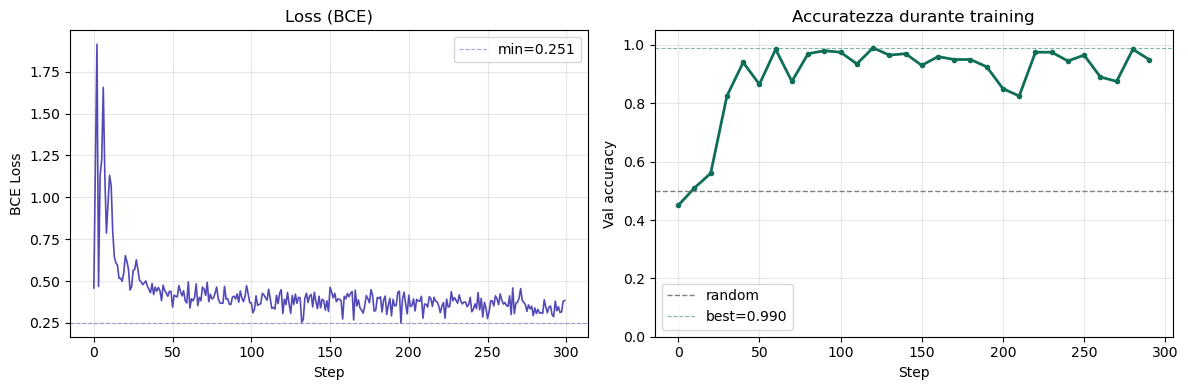

In [37]:
# TRAINING 

opt = qml.AdamOptimizer(stepsize=learning_rate)

loss_history=[]
acc_history=[]
best_acc=0.0

for i in range(steps):
    weights, cost_val = opt.step_and_cost(
        lambda w: cost_function(w, X_train, Y_train, batch_size), weights
    )
    loss_history.append(float(cost_val))
    
    if i % 10 == 0:
        print(f"Step {i}, Cost {cost_val:.4f}")
        val_idx   = np.random.choice(len(X_test), size=200, replace=False)
        val_preds = [1 if circuit(x, weights) >= 0 else -1 for x in X_test[val_idx]]
        val_acc   = float(np.mean(np.array(val_preds) == np.array(Y_test[val_idx])))
        acc_history.append((i, val_acc))

        if val_acc > best_acc:
            best_acc     = val_acc
            best_weights = pnp.array(weights)

print(f"\nMigliore val acc: {best_acc:.3f}")
weights = best_weights


#PLOT TRAINING

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_history, color="#534AB7", linewidth=1.2)
axes[0].axhline(min(loss_history), color="#534AB7", linewidth=0.8,
                linestyle="--", alpha=0.5, label=f"min={min(loss_history):.3f}")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Loss (BCE)"); axes[0].legend(); axes[0].grid(alpha=0.3)

steps_a, accs_a = zip(*acc_history) if acc_history else ([], [])
axes[1].plot(steps_a, accs_a, color="#0F6E56", linewidth=2, marker="o", markersize=3)
axes[1].axhline(0.5, color="gray", linewidth=1, linestyle="--", label="random")
axes[1].axhline(best_acc, color="#0F6E56", linewidth=0.8, linestyle="--",
                alpha=0.5, label=f"best={best_acc:.3f}")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("Val accuracy")
axes[1].set_title("Accuratezza durante training")
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


  AE SINKCLASS — classificatore classico (BCE)
  Accuracy AE classifier : 97.15%
  AUC      AE classifier : 0.9958
  Score medio su signal  : 0.9476
  Score medio su bkg     : 0.0247


  PQC — classificatore quantistico
  Accuracy  : 97.05%
  AUC       : 0.9951
  F1 score  : 0.9724
  Precision : 0.9541
  Recall    : 0.9914
  Cost test : 0.4491


  Matrice di confusione (righe=vero, col=pred):
               pred+1  pred-1
  vero  +1  :   1039       9
  vero  -1  :     50     902

  Score PQC medio su signal : 0.4142
  Score PQC medio su bkg    : -0.3896




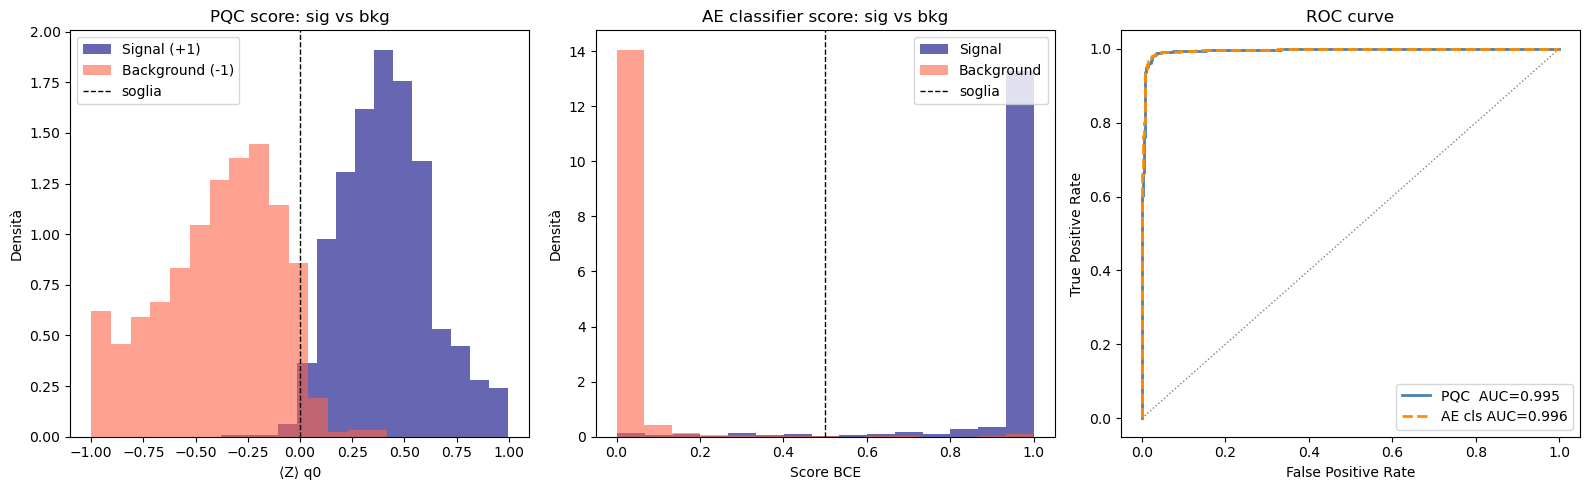

In [39]:
# TEST
test_predictions = [circuit(x, weights) for x in X_test]


# EVALUATION TEST
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

pred_labels = [1 if p >= 0 else -1 for p in test_predictions]
scores_np   = np.array([float(p) for p in test_predictions])
Y_test_np   = np.array(Y_test)
pred_np     = np.array(pred_labels)

accuracy  = np.mean(pred_np == Y_test_np)
test_cost = cost_function(weights, X_test, Y_test, batch_size)

# AUC 
Y_bin = ((Y_test_np + 1) / 2).astype(int)
s_bin = (scores_np + 1) / 2
auc   = roc_auc_score(Y_bin, s_bin)
fpr, tpr, _ = roc_curve(Y_bin, s_bin)

cm = confusion_matrix(Y_test_np, pred_np, labels=[1,-1])
TP, FN = cm[0,0], cm[0,1]
FP, TN = cm[1,0], cm[1,1]
precision  = TP / (TP + FP) if (TP + FP) > 0 else 0
recall     = TP / (TP + FN) if (TP + FN) > 0 else 0
f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# AE classifier 
print("")
print("  AE SINKCLASS — classificatore classico (BCE)")
with torch.no_grad():
    _, ae_scores, _ = model.forward(torch.tensor(X_te, dtype=torch.float32))
    ae_scores_np = ae_scores.cpu().numpy().flatten()
ae_pred  = (ae_scores_np >= 0.5).astype(int)
ae_acc   = np.mean(ae_pred == Y_te.astype(int))
ae_auc   = roc_auc_score(Y_te.astype(int), ae_scores_np)
print(f"  Accuracy AE classifier : {ae_acc*100:.2f}%")
print(f"  AUC      AE classifier : {ae_auc:.4f}")
print(f"  Score medio su signal  : {ae_scores_np[Y_te==1].mean():.4f}")
print(f"  Score medio su bkg     : {ae_scores_np[Y_te==0].mean():.4f}")

# PQC 
print("")
print("")
print("  PQC — classificatore quantistico")
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  AUC       : {auc:.4f}")
print(f"  F1 score  : {f1:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  Cost test : {test_cost:.4f}")
print("")
print(f"\n  Matrice di confusione (righe=vero, col=pred):")
print(f"               pred+1  pred-1")
print(f"  vero  +1  :  {TP:5d}   {FN:5d}")
print(f"  vero  -1  :  {FP:5d}   {TN:5d}")
print(f"\n  Score PQC medio su signal : {scores_np[Y_test_np== 1].mean():.4f}")
print(f"  Score PQC medio su bkg    : {scores_np[Y_test_np==-1].mean():.4f}")
print("")
print("")


# PLOTS

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# score PQC sig vs bkg
axes[0].hist(scores_np[Y_test_np== 1], bins=15, alpha=0.6,
             color="navy",   label="Signal (+1)", density=True)
axes[0].hist(scores_np[Y_test_np==-1], bins=15, alpha=0.6,
             color="tomato", label="Background (-1)", density=True)
axes[0].axvline(0, color="black", linewidth=1, linestyle="--", label="soglia")
axes[0].set_title("PQC score: sig vs bkg")
axes[0].set_xlabel("⟨Z⟩ q0")
axes[0].set_ylabel("Densità")
axes[0].legend()

# score AE classifier sig vs bkg
axes[1].hist(ae_scores_np[Y_te==1], bins=15, alpha=0.6,
             color="navy",   label="Signal", density=True)
axes[1].hist(ae_scores_np[Y_te==0], bins=15, alpha=0.6,
             color="tomato", label="Background", density=True)
axes[1].axvline(0.5, color="black", linewidth=1, linestyle="--", label="soglia")
axes[1].set_title("AE classifier score: sig vs bkg")
axes[1].set_xlabel("Score BCE")
axes[1].set_ylabel("Densità")
axes[1].legend()

# ROC curve
axes[2].plot(fpr, tpr, color="steelblue", linewidth=2, label=f"PQC  AUC={auc:.3f}")
ae_fpr, ae_tpr, _ = roc_curve(Y_te.astype(int), ae_scores_np)
axes[2].plot(ae_fpr, ae_tpr, color="darkorange", linewidth=2,
             linestyle="--", label=f"AE cls AUC={ae_auc:.3f}")
axes[2].plot([0,1], [0,1], color="gray", linewidth=1, linestyle=":")
axes[2].set_title("ROC curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

plt.tight_layout()
plt.show()

Per visualizzare il circuito a un qubit:

In [20]:
#STAMPA CIRCUITO

print(qml.draw(circuit)(X_train[0], weights))

0: ──RY(1.83)──RY(5.64)──RZ(5.39)──RX(0.58)──RY(1.58)──RY(4.88)──RZ(4.11)──RX(4.06)──RY(1.69) ···

0: ··· ──RY(5.23)──RZ(0.66)──RX(5.75)──RY(1.62)──RY(3.81)──RZ(3.59)──RX(5.99)──RY(1.39) ···

0: ··· ──RY(4.79)──RZ(5.21)──RX(4.19)──RY(1.76)──RY(3.77)──RZ(3.42)──RX(0.06)──RY(1.51) ···

0: ··· ──RY(5.46)──RZ(0.69)──RX(5.42)──RY(1.78)──RY(0.31)──RZ(0.37)──RX(5.53)──RY(1.61) ···

0: ··· ──RY(0.49)──RZ(1.74)──RX(1.58)──RY(1.44)──RY(2.43)──RZ(5.78)──RX(4.00)──RY(1.56) ···

0: ··· ──RY(5.28)──RZ(5.48)──RX(5.09)──RY(1.64)──RY(6.07)──RZ(3.06)──RX(3.22)──RY(1.72) ···

0: ··· ──RY(0.34)──RZ(4.06)──RX(0.68)──RY(1.49)──RY(5.10)──RZ(3.86)──RX(5.66)──RY(1.52) ···

0: ··· ──RY(5.38)──RZ(2.72)──RX(0.74)──RY(1.72)──RY(0.32)──RZ(2.09)──RX(0.26)─┤  <Z>


Si nota che il valore dell'accuracy del test è aumentato rispetto al caso senza re-uploading, nonostante l'uso di un solo qubit.

# 4 qubits

Secondo l'articolo citato, si può ancora migliorare la prestazione del classificatore aggiungendo dei qubits: nel seguente circuito le 16 features vengono quindi codificate in 4 qubits attraverso 4 layers.

In [40]:
# 4 QUBITS, 16 FEATURES, RE-UPLOADING

n_qubits      = 4
n_layers      = 4
steps         = 300
learning_rate = 0.1
batch_size=20

dev = qml.device("default.qubit", wires=n_qubits)

# DEFINIZIONI

def structured_ansatz(weights, wires): #layer
    for i in range(len(wires)):
        qml.RX(weights[i,0], wires=wires[i])
        qml.RY(weights[i,1], wires=wires[i])
        qml.RZ(weights[i,2], wires=wires[i])
    for i in range(len(wires)-1):
        qml.CNOT(wires=[i,i+1])
    qml.CNOT(wires=[len(wires)-1,0])

def pqc(weights, x_sample): 
    x = x_sample.flatten()
    for layer in range(n_layers):
        for i in range(n_qubits):
            feature_index = layer*n_qubits + i
            qml.RY(x[feature_index], wires=i) #angle encoding
        structured_ansatz(weights[layer], wires=range(n_qubits))

@qml.qnode(dev, interface="autograd")
def circuit(weights, x_sample): #circuito completo
    pqc(weights, x_sample) 
    return qml.expval(qml.PauliZ(0)) #misura solo sul primo qubit


def cost_function(weights, X, Y, batch_size, eps=1e-7):
    Y_arr   = np.array(Y)
    idx_pos = np.where(Y_arr ==  1)[0]
    idx_neg = np.where(Y_arr == -1)[0]
    half    = batch_size // 2

    chosen_pos = np.random.choice(idx_pos, size=min(half, len(idx_pos)), replace=False)
    chosen_neg = np.random.choice(idx_neg, size=min(half, len(idx_neg)), replace=False)
    idx = np.concatenate([chosen_pos, chosen_neg])
    np.random.shuffle(idx)

    X_batch = pnp.array(X[idx])
    Y_batch = pnp.array((Y_arr[idx] + 1) / 2)  

    preds_raw = pnp.array([circuit(weights, x) for x in X_batch])

    probs = (preds_raw + 1) / 2              
    probs = pnp.clip(probs, eps, 1 - eps)

    return -pnp.mean(
        Y_batch * pnp.log(probs) + (1 - Y_batch) * pnp.log(1 - probs)
    )

weights = pnp.array(
    pnp.random.uniform(0, 2*pnp.pi, size=(n_layers, n_qubits, 3)),
    requires_grad=True
)


Step 0, Cost 0.6241
Step 10, Cost 0.5255
Step 20, Cost 0.4694
Step 30, Cost 0.4794
Step 40, Cost 0.4172
Step 50, Cost 0.4787
Step 60, Cost 0.5100
Step 70, Cost 0.4730
Step 80, Cost 0.3926
Step 90, Cost 0.4538
Step 100, Cost 0.4454
Step 110, Cost 0.4446
Step 120, Cost 0.4937
Step 130, Cost 0.4822
Step 140, Cost 0.4718
Step 150, Cost 0.4376
Step 160, Cost 0.4862
Step 170, Cost 0.5077
Step 180, Cost 0.4599
Step 190, Cost 0.4794
Step 200, Cost 0.4525
Step 210, Cost 0.4652
Step 220, Cost 0.4426
Step 230, Cost 0.4257
Step 240, Cost 0.4488
Step 250, Cost 0.4731
Step 260, Cost 0.4841
Step 270, Cost 0.4835
Step 280, Cost 0.4721
Step 290, Cost 0.4024

Migliore val acc: 0.985


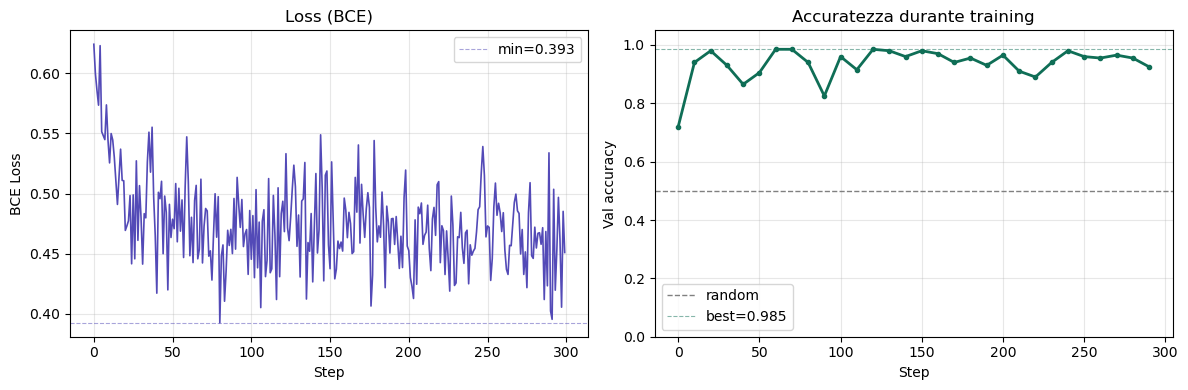

In [41]:
# TRAINING 

opt = qml.AdamOptimizer(stepsize=learning_rate)

loss_history=[]
acc_history=[]
best_acc=0.0


for i in range(steps):
    weights, cost_val = opt.step_and_cost(
        lambda w: cost_function(w, X_train, Y_train, batch_size), weights
    )
    loss_history.append(float(cost_val))
    
    if i % 10 == 0:
        print(f"Step {i}, Cost {cost_val:.4f}")
        val_idx   = np.random.choice(len(X_test), size=200, replace=False)
        val_preds = [1 if circuit(weights, x) >= 0 else -1 for x in X_test[val_idx]]
        val_acc   = float(np.mean(np.array(val_preds) == np.array(Y_test[val_idx])))
        acc_history.append((i, val_acc))

        if val_acc > best_acc:
            best_acc     = val_acc
            best_weights = pnp.array(weights)

print(f"\nMigliore val acc: {best_acc:.3f}")
weights = best_weights

            
# PLOT TRAINING

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_history, color="#534AB7", linewidth=1.2)
axes[0].axhline(min(loss_history), color="#534AB7", linewidth=0.8,
                linestyle="--", alpha=0.5, label=f"min={min(loss_history):.3f}")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Loss (BCE)"); axes[0].legend(); axes[0].grid(alpha=0.3)

steps_a, accs_a = zip(*acc_history) if acc_history else ([], [])
axes[1].plot(steps_a, accs_a, color="#0F6E56", linewidth=2, marker="o", markersize=3)
axes[1].axhline(0.5, color="gray", linewidth=1, linestyle="--", label="random")
axes[1].axhline(best_acc, color="#0F6E56", linewidth=0.8, linestyle="--",
                alpha=0.5, label=f"best={best_acc:.3f}")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("Val accuracy")
axes[1].set_title("Accuratezza durante training")
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


  AE SINKCLASS — classificatore classico (BCE)
  Accuracy AE classifier : 97.15%
  AUC      AE classifier : 0.9958
  Score medio su signal  : 0.9476
  Score medio su bkg     : 0.0247


  PQC — classificatore quantistico
  Accuracy  : 97.25%
  AUC       : 0.9949
  F1 score  : 0.9737
  Precision : 0.9742
  Recall    : 0.9733
  Cost test : 0.4500


  Matrice di confusione (righe=vero, col=pred):

               pred+1  pred-1
  vero  +1  :   1020      28
  vero  -1  :     27     925

  Score PQC medio su signal : 0.2587
  Score PQC medio su bkg    : -0.2676



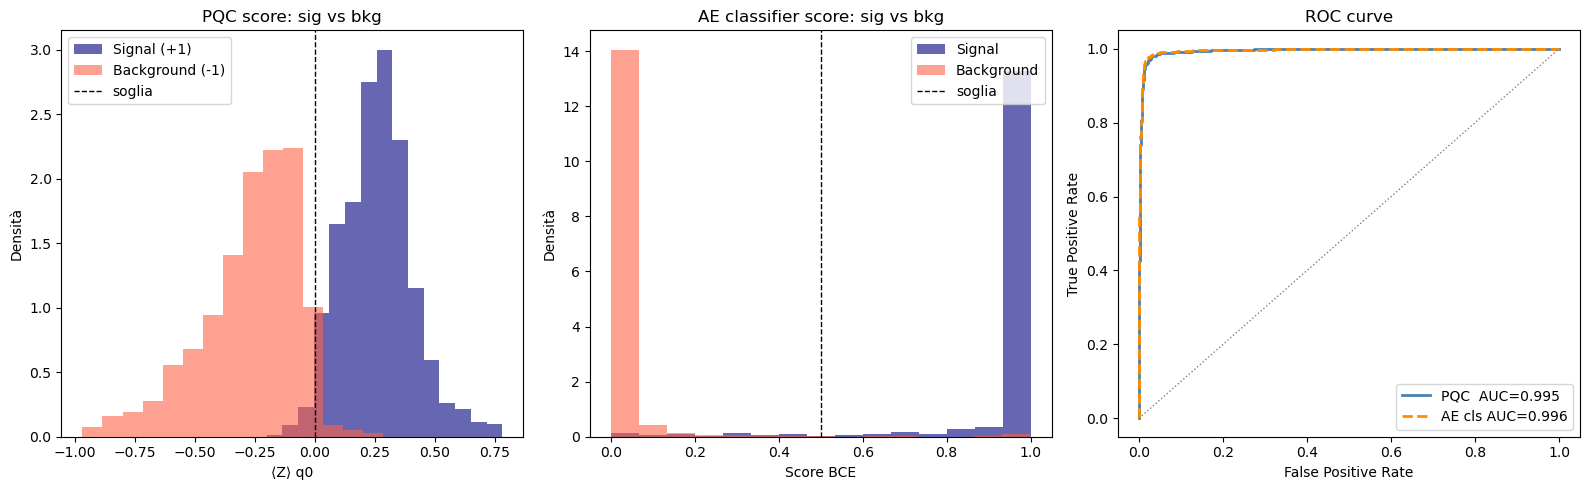

In [42]:
# TEST

test_predictions = [circuit(weights, x) for x in X_test]


# EVALUATION TEST

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

pred_labels = [1 if p >= 0 else -1 for p in test_predictions]
scores_np   = np.array([float(p) for p in test_predictions])
Y_test_np   = np.array(Y_test)
pred_np     = np.array(pred_labels)

accuracy  = np.mean(pred_np == Y_test_np)
test_cost = cost_function(weights, X_test, Y_test, batch_size)

# AUC 
Y_bin = ((Y_test_np + 1) / 2).astype(int)
s_bin = (scores_np + 1) / 2
auc   = roc_auc_score(Y_bin, s_bin)
fpr, tpr, _ = roc_curve(Y_bin, s_bin)

cm = confusion_matrix(Y_test_np, pred_np, labels=[1,-1])
TP, FN = cm[0,0], cm[0,1]
FP, TN = cm[1,0], cm[1,1]
precision  = TP / (TP + FP) if (TP + FP) > 0 else 0
recall     = TP / (TP + FN) if (TP + FN) > 0 else 0
f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# AE classifier
print("")
print("  AE SINKCLASS — classificatore classico (BCE)")
with torch.no_grad():
    _, ae_scores, _ = model.forward(torch.tensor(X_te, dtype=torch.float32))
    ae_scores_np = ae_scores.cpu().numpy().flatten()
ae_pred  = (ae_scores_np >= 0.5).astype(int)
ae_acc   = np.mean(ae_pred == Y_te.astype(int))
ae_auc   = roc_auc_score(Y_te.astype(int), ae_scores_np)
print(f"  Accuracy AE classifier : {ae_acc*100:.2f}%")
print(f"  AUC      AE classifier : {ae_auc:.4f}")
print(f"  Score medio su signal  : {ae_scores_np[Y_te==1].mean():.4f}")
print(f"  Score medio su bkg     : {ae_scores_np[Y_te==0].mean():.4f}")

# PQC 
print("")
print("")
print("  PQC — classificatore quantistico")
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  AUC       : {auc:.4f}")
print(f"  F1 score  : {f1:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  Cost test : {test_cost:.4f}")
print("")
print(f"\n  Matrice di confusione (righe=vero, col=pred):")
print("")
print(f"               pred+1  pred-1")
print(f"  vero  +1  :  {TP:5d}   {FN:5d}")
print(f"  vero  -1  :  {FP:5d}   {TN:5d}")
print(f"\n  Score PQC medio su signal : {scores_np[Y_test_np== 1].mean():.4f}")
print(f"  Score PQC medio su bkg    : {scores_np[Y_test_np==-1].mean():.4f}")
print("")


# PLOT

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Grafico score PQC sig vs bkg
axes[0].hist(scores_np[Y_test_np== 1], bins=15, alpha=0.6,
             color="navy",   label="Signal (+1)", density=True)
axes[0].hist(scores_np[Y_test_np==-1], bins=15, alpha=0.6,
             color="tomato", label="Background (-1)", density=True)
axes[0].axvline(0, color="black", linewidth=1, linestyle="--", label="soglia")
axes[0].set_title("PQC score: sig vs bkg")
axes[0].set_xlabel("⟨Z⟩ q0")
axes[0].set_ylabel("Densità")
axes[0].legend()

# Grafico score AE classifier sig vs bkg
axes[1].hist(ae_scores_np[Y_te==1], bins=15, alpha=0.6,
             color="navy",   label="Signal", density=True)
axes[1].hist(ae_scores_np[Y_te==0], bins=15, alpha=0.6,
             color="tomato", label="Background", density=True)
axes[1].axvline(0.5, color="black", linewidth=1, linestyle="--", label="soglia")
axes[1].set_title("AE classifier score: sig vs bkg")
axes[1].set_xlabel("Score BCE")
axes[1].set_ylabel("Densità")
axes[1].legend()

# ROC curve AE e PQC
axes[2].plot(fpr, tpr, color="steelblue", linewidth=2, label=f"PQC  AUC={auc:.3f}")
ae_fpr, ae_tpr, _ = roc_curve(Y_te.astype(int), ae_scores_np)
axes[2].plot(ae_fpr, ae_tpr, color="darkorange", linewidth=2,
             linestyle="--", label=f"AE cls AUC={ae_auc:.3f}")
axes[2].plot([0,1], [0,1], color="gray", linewidth=1, linestyle=":")
axes[2].set_title("ROC curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

plt.tight_layout()
plt.show()

In [23]:
#STAMPA CIRCUITO

print(qml.draw(circuit)(weights, X_train))

0: ──RY(1.83)──RX(-0.35)──RY(2.67)──RZ(2.55)─╭●───────╭X──RY(1.39)──RX(3.62)──RY(6.47) ···
1: ──RY(1.58)──RX(5.15)───RY(0.95)──RZ(1.29)─╰X─╭●────│───RY(1.76)──RX(2.51)──RY(1.75) ···
2: ──RY(1.69)──RX(1.76)───RY(5.81)──RZ(4.58)────╰X─╭●─│───RY(1.51)──RX(2.39)──RY(5.97) ···
3: ──RY(1.62)──RX(1.05)───RY(0.94)──RZ(4.38)───────╰X─╰●──RY(1.78)──RX(2.31)──RY(1.40) ···

0: ··· ──RZ(3.97)──╭●───────╭X──RY(1.61)──RX(5.17)───RY(1.17)───RZ(5.28)─╭●───────╭X──RY(1.72) ···
1: ··· ──RZ(0.52)──╰X─╭●────│───RY(1.44)──RX(6.28)───RY(3.51)───RZ(4.02)─╰X─╭●────│───RY(1.49) ···
2: ··· ──RZ(-0.94)────╰X─╭●─│───RY(1.56)──RX(-0.23)──RY(-0.48)──RZ(2.02)────╰X─╭●─│───RY(1.52) ···
3: ··· ──RZ(1.56)────────╰X─╰●──RY(1.64)──RX(2.56)───RY(5.63)───RZ(1.93)───────╰X─╰●──RY(1.72) ···

0: ··· ──RX(1.27)──RY(3.95)──RZ(2.06)─╭●───────╭X─┤  <Z>
1: ··· ──RX(5.96)──RY(5.66)──RZ(1.44)─╰X─╭●────│──┤     
2: ··· ──RX(2.81)──RY(3.87)──RZ(4.09)────╰X─╭●─│──┤     
3: ··· ──RX(2.43)──RY(1.97)──RZ(0.22)───────╰X─╰●─┤     


Il circuito risulta essere un ottimo modello per il problema. \
Si prova allora ad aumentare ancora il numero di qubits.

# 8 qubits

Step 0, Cost 0.6991
Step 10, Cost 0.5980
Step 20, Cost 0.6151
Step 30, Cost 0.5829
Step 40, Cost 0.5727
Step 50, Cost 0.5838
Step 60, Cost 0.5579
Step 70, Cost 0.6088
Step 80, Cost 0.5952
Step 90, Cost 0.5578
Step 100, Cost 0.5613
Step 110, Cost 0.5601
Step 120, Cost 0.5578
Step 130, Cost 0.5523
Step 140, Cost 0.5670
Step 150, Cost 0.5586
Step 160, Cost 0.5569
Step 170, Cost 0.5813
Step 180, Cost 0.5383
Step 190, Cost 0.5914
Step 200, Cost 0.5188
Step 210, Cost 0.5972
Step 220, Cost 0.5764
Step 230, Cost 0.5423
Step 240, Cost 0.5797
Step 250, Cost 0.5609
Step 260, Cost 0.5360
Step 270, Cost 0.5871
Step 280, Cost 0.5786
Step 290, Cost 0.5995

Migliore val acc: 0.985


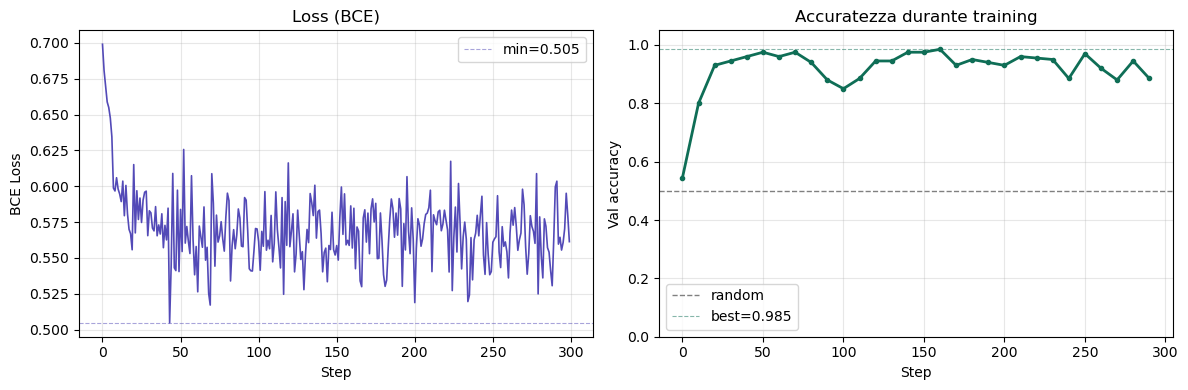

In [43]:
# 8 QUBITS, 16 FEATURES, RE-UPLOADING

n_qubits      = 8
n_layers      = 2
steps         = 300
learning_rate = 0.1

dev = qml.device("default.qubit", wires=n_qubits)

# DEFINIZIONI

def structured_ansatz(weights, wires): #layer
    for i in range(len(wires)):
        qml.RX(weights[i,0], wires=wires[i])
        qml.RY(weights[i,1], wires=wires[i])
        qml.RZ(weights[i,2], wires=wires[i])
    for i in range(len(wires)-1):
        qml.CNOT(wires=[i,i+1])
    qml.CNOT(wires=[len(wires)-1,0])

def pqc(weights, x_sample): 
    x = x_sample.flatten()
    for layer in range(n_layers):
        for i in range(n_qubits):
            feature_index = layer*n_qubits + i
            qml.RY(x[feature_index], wires=i) #angle encoding
        structured_ansatz(weights[layer], wires=range(n_qubits))

@qml.qnode(dev, interface="autograd")
def circuit(weights, x_sample): #circuito completo
    pqc(weights, x_sample) 
    return qml.expval(qml.PauliZ(0)) #misura solo sul primo qubit


def cost_function(weights, X, Y, batch_size=20, eps=1e-7):
    Y_arr   = np.array(Y)
    idx_pos = np.where(Y_arr ==  1)[0]
    idx_neg = np.where(Y_arr == -1)[0]
    half    = batch_size // 2

    chosen_pos = np.random.choice(idx_pos, size=min(half, len(idx_pos)), replace=False)
    chosen_neg = np.random.choice(idx_neg, size=min(half, len(idx_neg)), replace=False)
    idx = np.concatenate([chosen_pos, chosen_neg])
    np.random.shuffle(idx)

    X_batch = pnp.array(X[idx])
    Y_batch = pnp.array((Y_arr[idx] + 1) / 2)  

    preds_raw = pnp.array([circuit(weights, x) for x in X_batch])

    probs = (preds_raw + 1) / 2              
    probs = pnp.clip(probs, eps, 1 - eps)

    return -pnp.mean(
        Y_batch * pnp.log(probs) + (1 - Y_batch) * pnp.log(1 - probs)
    )

weights = pnp.array(
    pnp.random.uniform(0, 2*pnp.pi, size=(n_layers, n_qubits, 3)),
    requires_grad=True
)

opt = qml.AdamOptimizer(stepsize=learning_rate)


# TRAINING 

loss_history=[]
acc_history=[]
best_acc=0.0


for i in range(steps):
    weights, cost_val = opt.step_and_cost(
        lambda w: cost_function(w, X_train, Y_train), weights
    )
    loss_history.append(float(cost_val))
    
    if i % 10 == 0:
        print(f"Step {i}, Cost {cost_val:.4f}")
        val_idx   = np.random.choice(len(X_test), size=200, replace=False)
        val_preds = [1 if circuit(weights, x) >= 0 else -1 for x in X_test[val_idx]]
        val_acc   = float(np.mean(np.array(val_preds) == np.array(Y_test[val_idx])))
        acc_history.append((i, val_acc))

        if val_acc > best_acc:
            best_acc     = val_acc
            best_weights = pnp.array(weights)

print(f"\nMigliore val acc: {best_acc:.3f}")
weights = best_weights

            
# PLOT TRAINING

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_history, color="#534AB7", linewidth=1.2)
axes[0].axhline(min(loss_history), color="#534AB7", linewidth=0.8,
                linestyle="--", alpha=0.5, label=f"min={min(loss_history):.3f}")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Loss (BCE)"); axes[0].legend(); axes[0].grid(alpha=0.3)

steps_a, accs_a = zip(*acc_history) if acc_history else ([], [])
axes[1].plot(steps_a, accs_a, color="#0F6E56", linewidth=2, marker="o", markersize=3)
axes[1].axhline(0.5, color="gray", linewidth=1, linestyle="--", label="random")
axes[1].axhline(best_acc, color="#0F6E56", linewidth=0.8, linestyle="--",
                alpha=0.5, label=f"best={best_acc:.3f}")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("Val accuracy")
axes[1].set_title("Accuratezza durante training")
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


  AE SINKCLASS — classificatore classico (BCE)
  Accuracy AE classifier : 97.15%
  AUC      AE classifier : 0.9958
  Score medio su signal  : 0.9476
  Score medio su bkg     : 0.0247


  PQC — classificatore quantistico
  Accuracy  : 96.20%
  AUC       : 0.9936
  F1 score  : 0.9642
  Precision : 0.9517
  Recall    : 0.9771
  Cost test : 0.5421


  Matrice di confusione (righe=vero, col=pred):

               pred+1  pred-1
  vero  +1  :   1024      24
  vero  -1  :     52     900

  Score PQC medio su signal : 0.1482
  Score PQC medio su bkg    : -0.1390



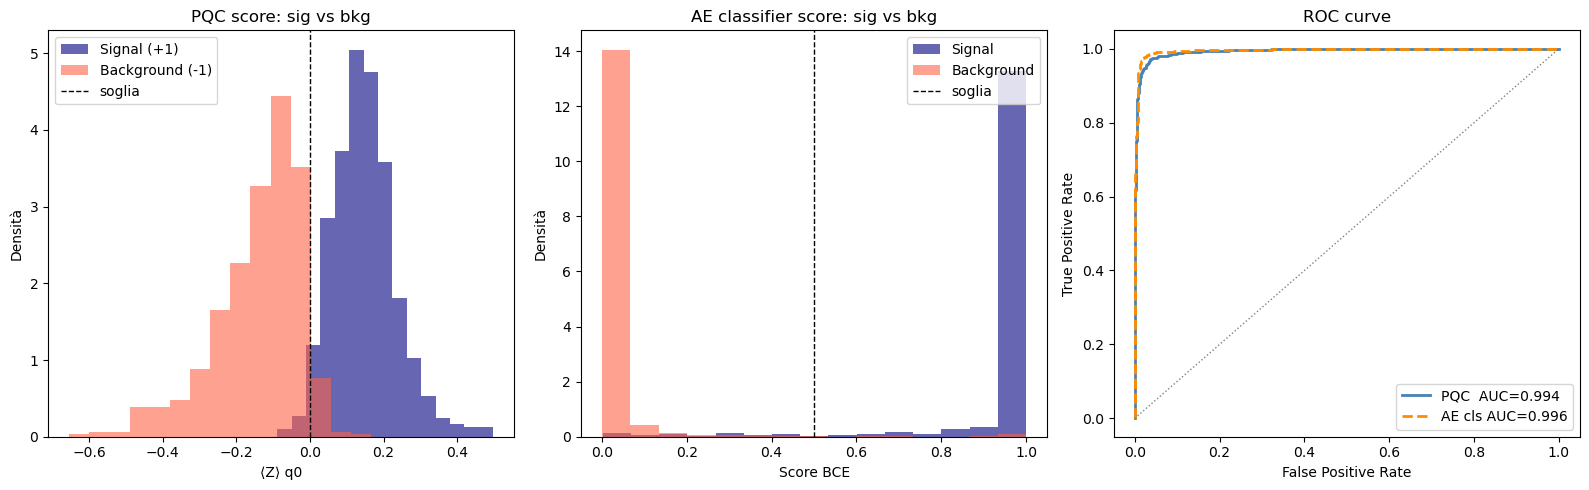

In [44]:
# TEST

test_predictions = [circuit(weights, x) for x in X_test]


# EVALUATION TEST

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

pred_labels = [1 if p >= 0 else -1 for p in test_predictions]
scores_np   = np.array([float(p) for p in test_predictions])
Y_test_np   = np.array(Y_test)
pred_np     = np.array(pred_labels)

accuracy  = np.mean(pred_np == Y_test_np)
test_cost = cost_function(weights, X_test, Y_test)

# AUC 
Y_bin = ((Y_test_np + 1) / 2).astype(int)
s_bin = (scores_np + 1) / 2
auc   = roc_auc_score(Y_bin, s_bin)
fpr, tpr, _ = roc_curve(Y_bin, s_bin)

cm = confusion_matrix(Y_test_np, pred_np, labels=[1,-1])
TP, FN = cm[0,0], cm[0,1]
FP, TN = cm[1,0], cm[1,1]
precision  = TP / (TP + FP) if (TP + FP) > 0 else 0
recall     = TP / (TP + FN) if (TP + FN) > 0 else 0
f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# AE classifier
print("")
print("  AE SINKCLASS — classificatore classico (BCE)")
with torch.no_grad():
    _, ae_scores, _ = model.forward(torch.tensor(X_te, dtype=torch.float32))
    ae_scores_np = ae_scores.cpu().numpy().flatten()
ae_pred  = (ae_scores_np >= 0.5).astype(int)
ae_acc   = np.mean(ae_pred == Y_te.astype(int))
ae_auc   = roc_auc_score(Y_te.astype(int), ae_scores_np)
print(f"  Accuracy AE classifier : {ae_acc*100:.2f}%")
print(f"  AUC      AE classifier : {ae_auc:.4f}")
print(f"  Score medio su signal  : {ae_scores_np[Y_te==1].mean():.4f}")
print(f"  Score medio su bkg     : {ae_scores_np[Y_te==0].mean():.4f}")

# PQC 
print("")
print("")
print("  PQC — classificatore quantistico")
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  AUC       : {auc:.4f}")
print(f"  F1 score  : {f1:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  Cost test : {test_cost:.4f}")
print("")
print(f"\n  Matrice di confusione (righe=vero, col=pred):")
print("")
print(f"               pred+1  pred-1")
print(f"  vero  +1  :  {TP:5d}   {FN:5d}")
print(f"  vero  -1  :  {FP:5d}   {TN:5d}")
print(f"\n  Score PQC medio su signal : {scores_np[Y_test_np== 1].mean():.4f}")
print(f"  Score PQC medio su bkg    : {scores_np[Y_test_np==-1].mean():.4f}")
print("")


# PLOT

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Grafico score PQC sig vs bkg
axes[0].hist(scores_np[Y_test_np== 1], bins=15, alpha=0.6,
             color="navy",   label="Signal (+1)", density=True)
axes[0].hist(scores_np[Y_test_np==-1], bins=15, alpha=0.6,
             color="tomato", label="Background (-1)", density=True)
axes[0].axvline(0, color="black", linewidth=1, linestyle="--", label="soglia")
axes[0].set_title("PQC score: sig vs bkg")
axes[0].set_xlabel("⟨Z⟩ q0")
axes[0].set_ylabel("Densità")
axes[0].legend()

# Grafico score AE classifier sig vs bkg
axes[1].hist(ae_scores_np[Y_te==1], bins=15, alpha=0.6,
             color="navy",   label="Signal", density=True)
axes[1].hist(ae_scores_np[Y_te==0], bins=15, alpha=0.6,
             color="tomato", label="Background", density=True)
axes[1].axvline(0.5, color="black", linewidth=1, linestyle="--", label="soglia")
axes[1].set_title("AE classifier score: sig vs bkg")
axes[1].set_xlabel("Score BCE")
axes[1].set_ylabel("Densità")
axes[1].legend()

# ROC curve AE e PQC
axes[2].plot(fpr, tpr, color="steelblue", linewidth=2, label=f"PQC  AUC={auc:.3f}")
ae_fpr, ae_tpr, _ = roc_curve(Y_te.astype(int), ae_scores_np)
axes[2].plot(ae_fpr, ae_tpr, color="darkorange", linewidth=2,
             linestyle="--", label=f"AE cls AUC={ae_auc:.3f}")
axes[2].plot([0,1], [0,1], color="gray", linewidth=1, linestyle=":")
axes[2].set_title("ROC curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

plt.tight_layout()
plt.show()


In [28]:
#STAMPA CIRCUITO

print(qml.draw(circuit)(weights, X_train))

0: ──RY(1.83)──RX(2.56)──RY(3.41)──RZ(3.33)──╭●───────────────────╭X──RY(1.61)──RX(0.06) ···
1: ──RY(1.58)──RX(0.18)──RY(6.47)──RZ(3.18)──╰X─╭●────────────────│───RY(1.44)──RX(4.25) ···
2: ──RY(1.69)──RX(3.54)──RY(4.18)──RZ(1.49)─────╰X─╭●─────────────│───RY(1.56)──RX(5.36) ···
3: ──RY(1.62)──RX(0.75)──RY(3.11)──RZ(0.04)────────╰X─╭●──────────│───RY(1.64)──RX(0.77) ···
4: ──RY(1.39)──RX(1.83)──RY(4.90)──RZ(2.06)───────────╰X─╭●───────│───RY(1.72)──RX(2.33) ···
5: ──RY(1.76)──RX(4.44)──RY(6.29)──RZ(3.16)──────────────╰X─╭●────│───RY(1.49)──RX(3.13) ···
6: ──RY(1.51)──RX(6.93)──RY(5.61)──RZ(-0.42)────────────────╰X─╭●─│───RY(1.52)──RX(1.64) ···
7: ──RY(1.78)──RX(3.72)──RY(5.67)──RZ(2.79)────────────────────╰X─╰●──RY(1.72)──RX(6.32) ···

0: ··· ──RY(5.30)──RZ(4.91)─╭●───────────────────╭X─┤  <Z>
1: ··· ──RY(3.27)──RZ(1.50)─╰X─╭●────────────────│──┤     
2: ··· ──RY(2.43)──RZ(4.21)────╰X─╭●─────────────│──┤     
3: ··· ──RY(2.92)──RZ(1.17)───────╰X─╭●──────────│──┤     
4: ··· ──RY(0.08)──

La performance risulta quasi equivalente (o leggermente inferiore) ai casi precedenti di 1 e 4 qubits.

In conclusione, il data re-uploading risulta essere molto efficace per la risoluzione del problema. Inoltre si sottolinea che in questo notebook sono state codificate 16 features in tutti i circuiti, mentre nel notebook precedente, caso senza re-uploading, se ne erano usate solo 8. Considerato questo, i casi con re-uploading risultano più veloci nella compilazione.

Nel prossimo notebook (VQAplots) si analizza il comportamento del fenomeno del barren plateau attraverso lo studio dell'andamento della varianza dei gradienti della loss function in funzione del numero di qubits del circuito.